# DTSA 5509 Final Project - Shares of Online News Prediction

In this project, I will try to predict the shares of online news, which is a regression problem. I think this topic is interesting because all of media websites and bloggers are trying to drive more traffic, and increasing shares of posts will be an effective startegy. In addition to predict the shares directly, the insights from this project may also inspire the author and website owner, like focusing on specific subjects or publishing on a specific weekday.

Besides, I manage my own blog, and that's why I am fascinated about this topic.

## Import Modeuls

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import FunctionTransformer

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import xgboost as xgb

## 1. Gather data, determine the method of data collection and provenance of the data

The data source is [Online News Popularity Data Set](https://archive.ics.uci.edu/ml/datasets/Online+News+Popularity#), which contains 39644 instance. The description of columns as below:

0. url:                           URL of the article
1. timedelta:                     Days between the article publication and the dataset acquisition
2. n_tokens_title:                Number of words in the title
3. n_tokens_content:              Number of words in the content
4. n_unique_tokens:               Rate of unique words in the content
5. n_non_stop_words:              Rate of non-stop words in the content
6. n_non_stop_unique_tokens:      Rate of unique non-stop words in the content
7. num_hrefs:                     Number of links
8. num_self_hrefs:                Number of links to other articles published by Mashable
9. num_imgs:                      Number of images
10. num_videos:                    Number of videos
11. average_token_length:          Average length of the words in the content
12. num_keywords:                  Number of keywords in the metadata
13. data_channel_is_lifestyle:     Is data channel 'Lifestyle'?
14. data_channel_is_entertainment: Is data channel 'Entertainment'?
15. data_channel_is_bus:           Is data channel 'Business'?
16. data_channel_is_socmed:        Is data channel 'Social Media'?
17. data_channel_is_tech:          Is data channel 'Tech'?
18. data_channel_is_world:         Is data channel 'World'?
19. kw_min_min:                    Worst keyword (min. shares)
20. kw_max_min:                    Worst keyword (max. shares)
21. kw_avg_min:                    Worst keyword (avg. shares)
22. kw_min_max:                    Best keyword (min. shares)
23. kw_max_max:                    Best keyword (max. shares)
24. kw_avg_max:                    Best keyword (avg. shares)
25. kw_min_avg:                    Avg. keyword (min. shares)
26. kw_max_avg:                    Avg. keyword (max. shares)
27. kw_avg_avg:                    Avg. keyword (avg. shares)
28. self_reference_min_shares:     Min. shares of referenced articles in Mashable
29. self_reference_max_shares:     Max. shares of referenced articles in Mashable
30. self_reference_avg_sharess:    Avg. shares of referenced articles in Mashable
31. weekday_is_monday:             Was the article published on a Monday?
32. weekday_is_tuesday:            Was the article published on a Tuesday?
33. weekday_is_wednesday:          Was the article published on a Wednesday?
34. weekday_is_thursday:           Was the article published on a Thursday?
35. weekday_is_friday:             Was the article published on a Friday?
36. weekday_is_saturday:           Was the article published on a Saturday?
37. weekday_is_sunday:             Was the article published on a Sunday?
38. is_weekend:                    Was the article published on the weekend?
39. LDA_00:                        Closeness to LDA topic 0
40. LDA_01:                        Closeness to LDA topic 1
41. LDA_02:                        Closeness to LDA topic 2
42. LDA_03:                        Closeness to LDA topic 3
43. LDA_04:                        Closeness to LDA topic 4
44. global_subjectivity:           Text subjectivity
45. global_sentiment_polarity:     Text sentiment polarity
46. global_rate_positive_words:    Rate of positive words in the content
47. global_rate_negative_words:    Rate of negative words in the content
48. rate_positive_words:           Rate of positive words among non-neutral tokens
49. rate_negative_words:           Rate of negative words among non-neutral tokens
50. avg_positive_polarity:         Avg. polarity of positive words
51. min_positive_polarity:         Min. polarity of positive words
52. max_positive_polarity:         Max. polarity of positive words
53. avg_negative_polarity:         Avg. polarity of negative  words
54. min_negative_polarity:         Min. polarity of negative  words
55. max_negative_polarity:         Max. polarity of negative  words
56. title_subjectivity:            Title subjectivity
57. title_sentiment_polarity:      Title polarity
58. abs_title_subjectivity:        Absolute subjectivity level
59. abs_title_sentiment_polarity:  Absolute polarity level
60. shares:                        Number of shares (target)

In [4]:
data = pd.read_csv('/Users/aron/Documents/GitHub/DTSA-5509-Final-Project/OnlineNewsPopularity.csv')
data.head(5)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [5]:
print('The dataset has ', len(data), ' rows, and ', len(data.columns), ' factors.')

The dataset has  39644  rows, and  61  factors.


In [6]:
print(data.dtypes)

url                               object
 timedelta                       float64
 n_tokens_title                  float64
 n_tokens_content                float64
 n_unique_tokens                 float64
                                  ...   
 title_subjectivity              float64
 title_sentiment_polarity        float64
 abs_title_subjectivity          float64
 abs_title_sentiment_polarity    float64
 shares                            int64
Length: 61, dtype: object


## 2. Data Cleaning

**Check rows with null values**  
Because the rows with null values are rare, so I decid to drop these rows.

In [7]:
null_num = data.isnull().sum()
null_num = null_num[null_num > 0]
print(null_num)

 n_unique_tokens     4
 n_non_stop_words    6
dtype: int64


In [8]:
null_cols = list(null_num.index)
data = data.dropna(subset=null_cols, axis=0)

**Remove spaces in the column name**

Most of the columns have a blank at the begging, I remove them to prevent my code messy.

In [9]:
cols = list(data.columns)
print(cols)

['url', ' timedelta', ' n_tokens_title', ' n_tokens_content', ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle', ' data_channel_is_entertainment', ' data_channel_is_bus', ' data_channel_is_socmed', ' data_channel_is_tech', ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min', ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg', ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares', ' self_reference_max_shares', ' self_reference_avg_sharess', ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04', ' global_subjectivity', ' global_sentiment_polarity', ' global_rate_positive_words', ' global_rate_negative_words', ' rate_positive_words', '

In [10]:
cols = [c.replace(' ', '') for c in cols]
data.columns = cols

**Drop unmeaningful columns**

In [11]:
chk_dtype = data.dtypes
chk_dtype = chk_dtype[chk_dtype=='object']
chk_dtype

url    object
dtype: object

In [12]:
data = data.drop(['url', 'timedelta'], axis=1)

## 3. Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data

### Describe the factors with plots  
The range of each column is different, so it's not a good way to set a common width for all columns. The solution I use is to divide all the values into 20 bins.

/Users/aron/opt/anaconda3/lib/python3.8/site-packages/seaborn/axisgrid.py:392: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, axes = plt.subplots(nrow, ncol, **kwargs)


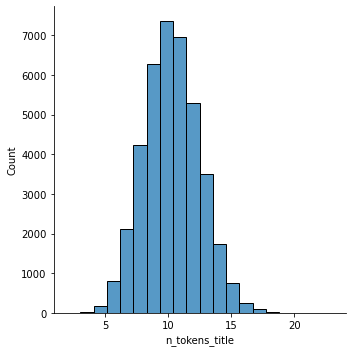

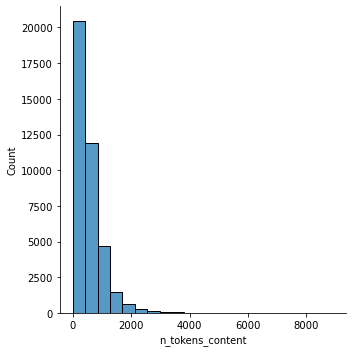

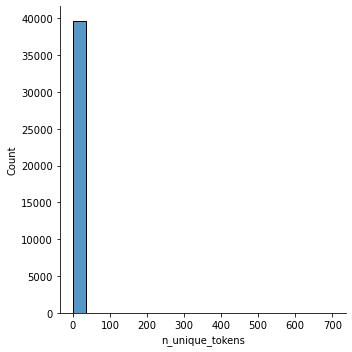

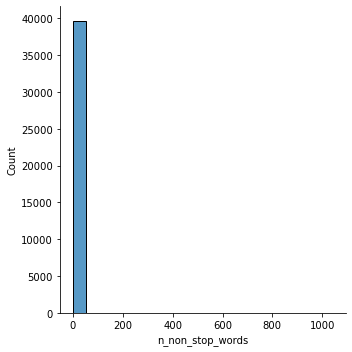

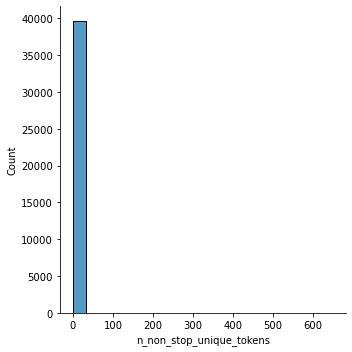

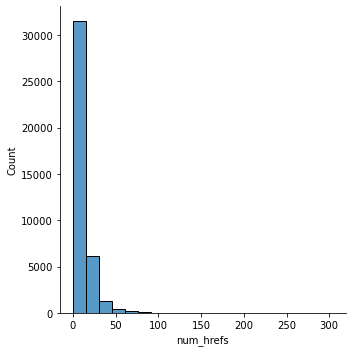

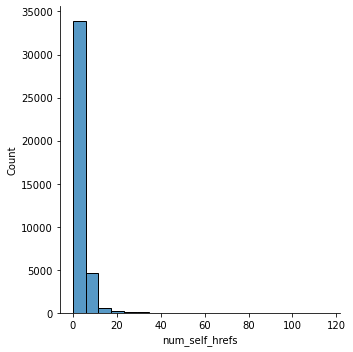

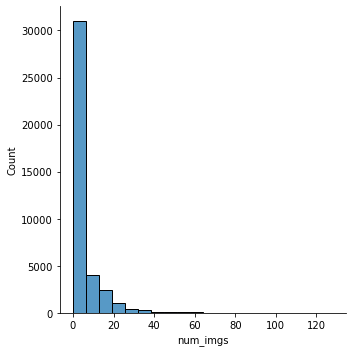

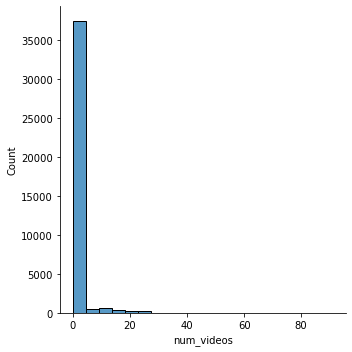

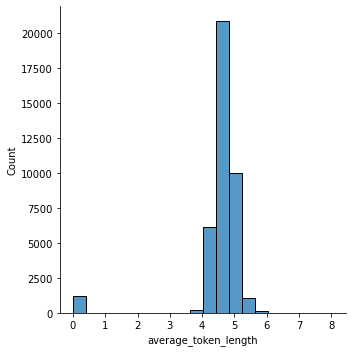

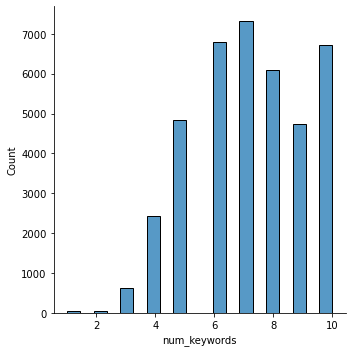

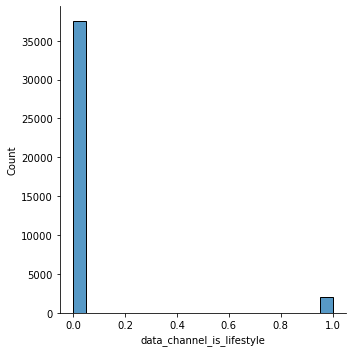

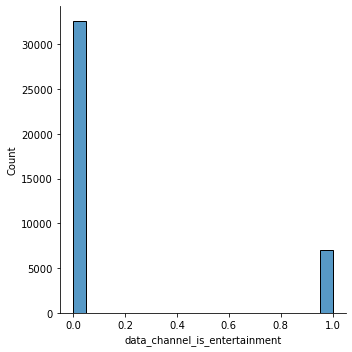

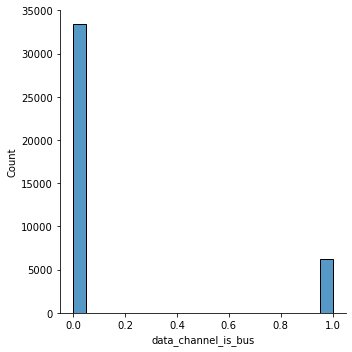

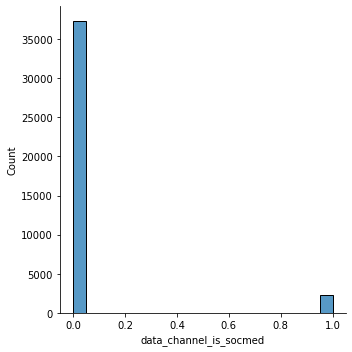

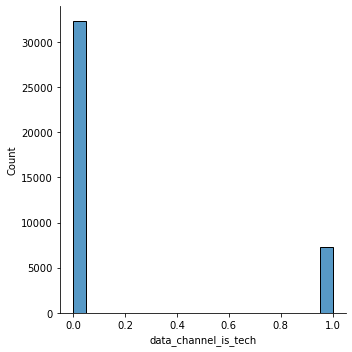

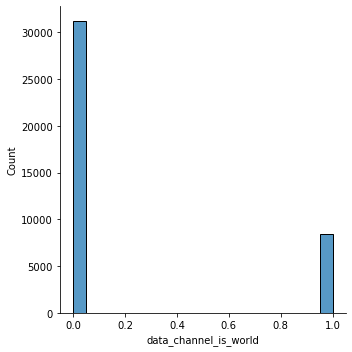

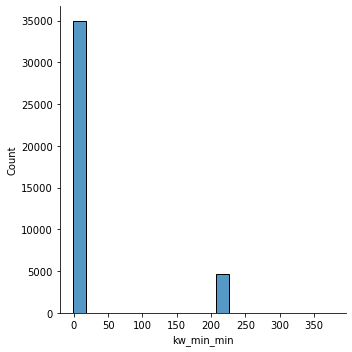

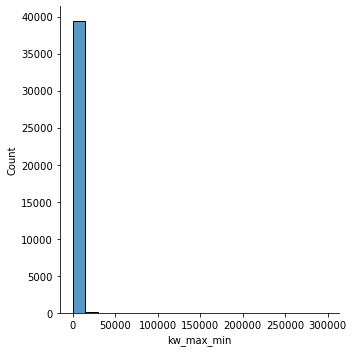

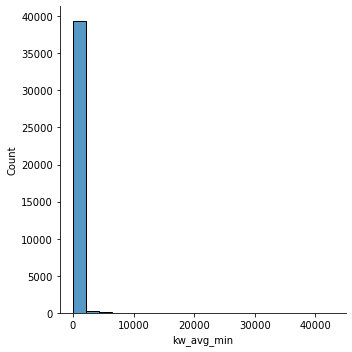

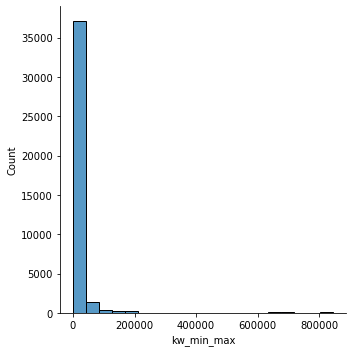

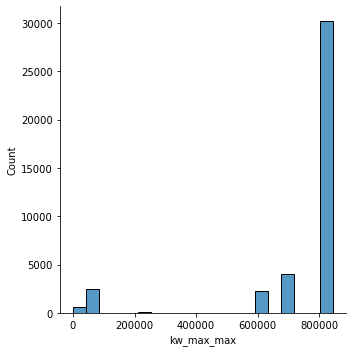

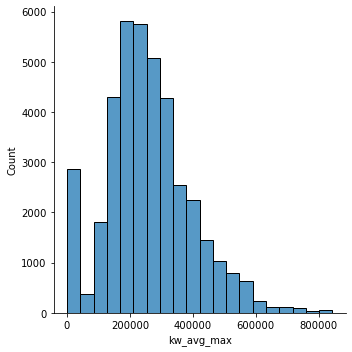

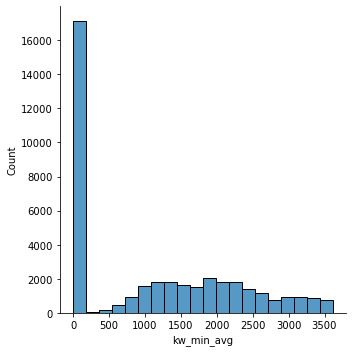

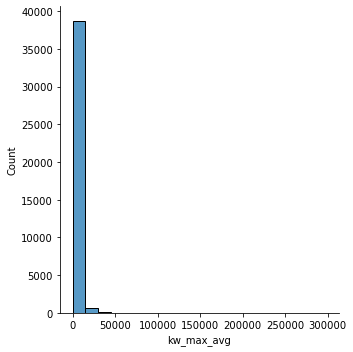

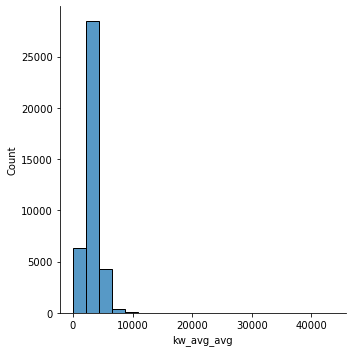

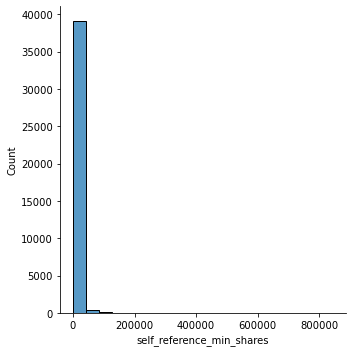

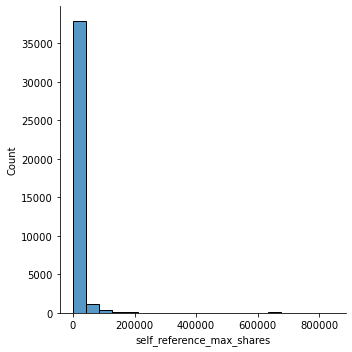

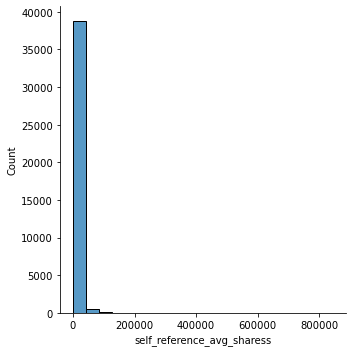

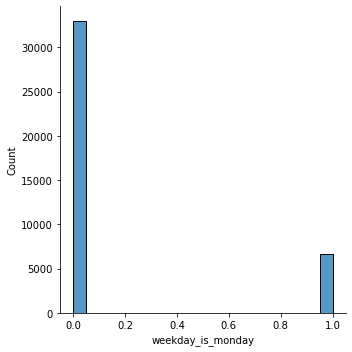

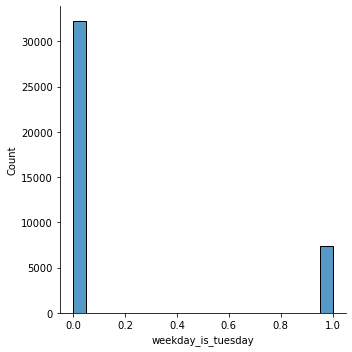

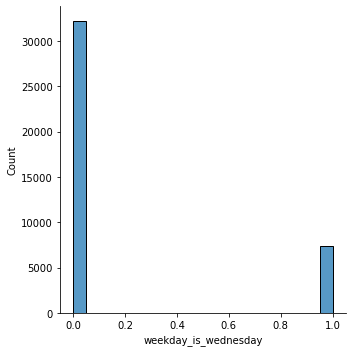

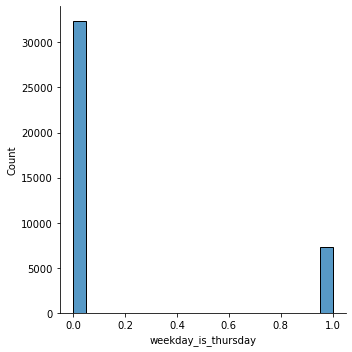

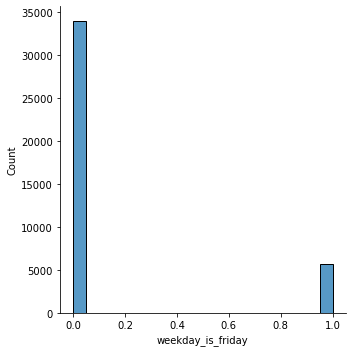

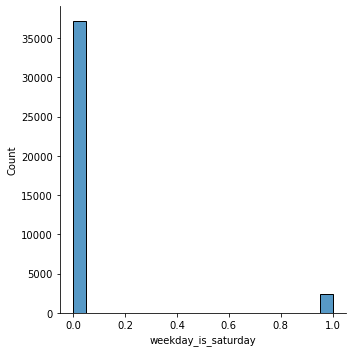

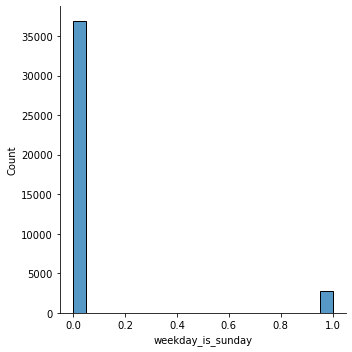

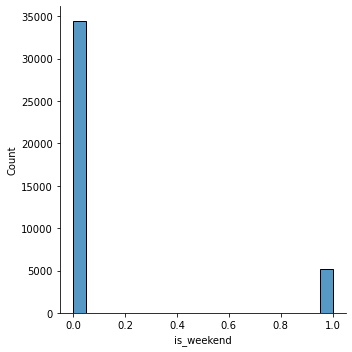

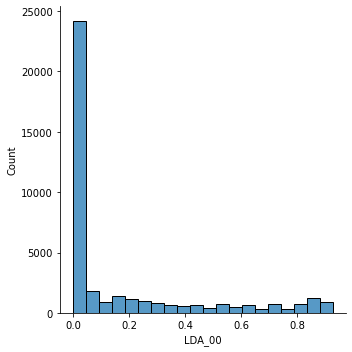

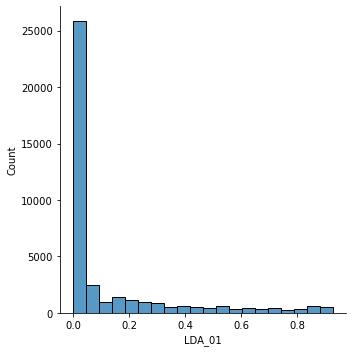

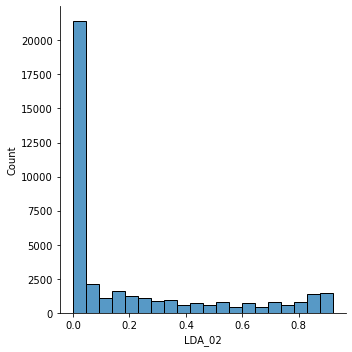

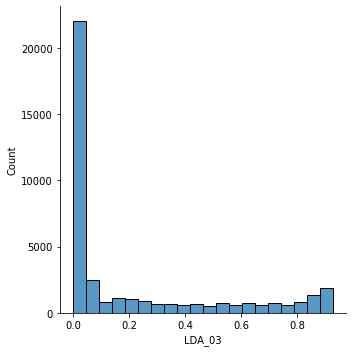

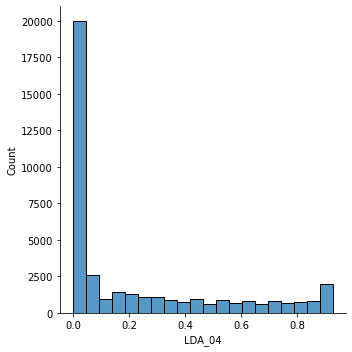

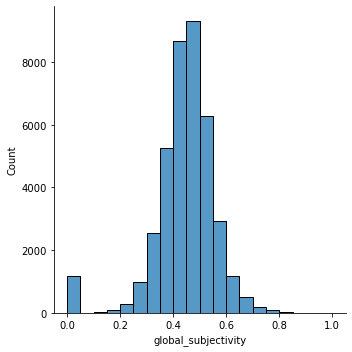

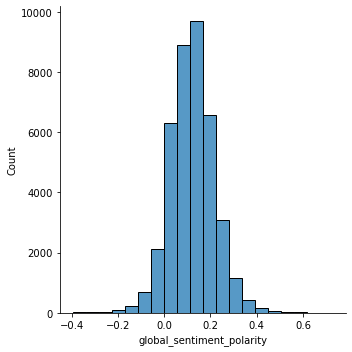

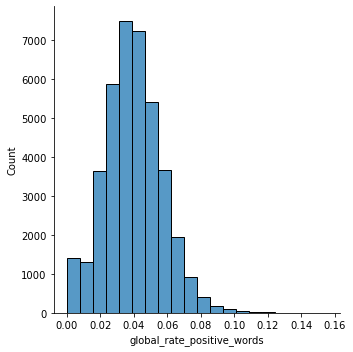

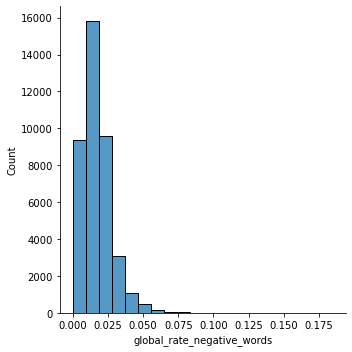

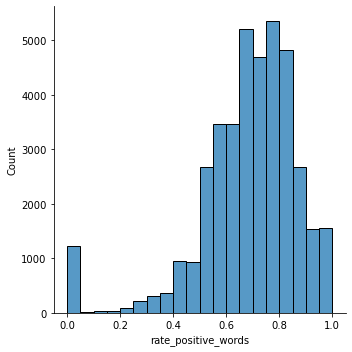

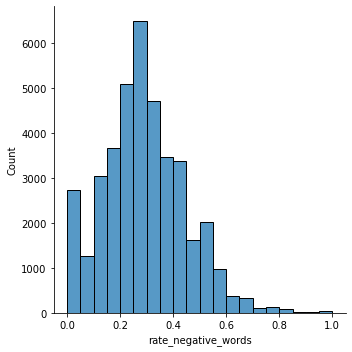

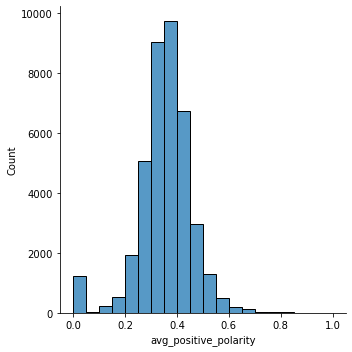

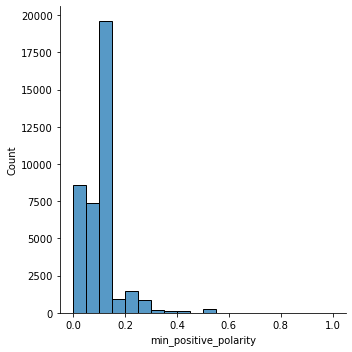

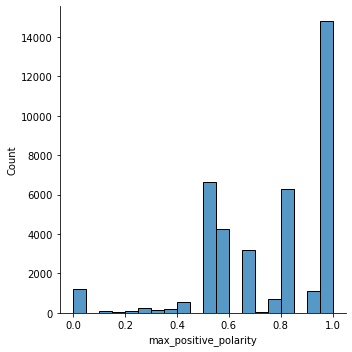

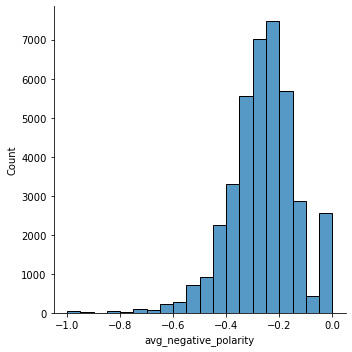

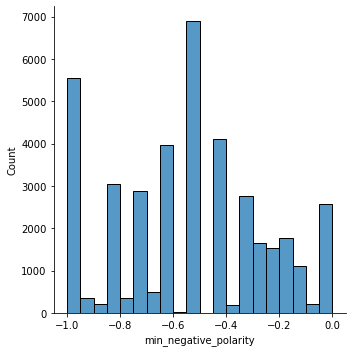

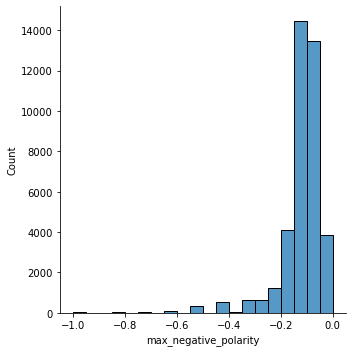

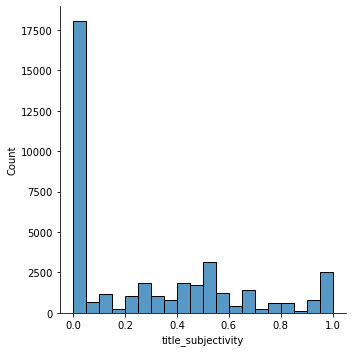

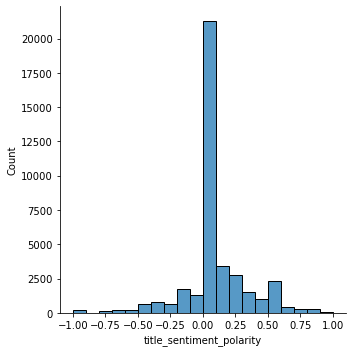

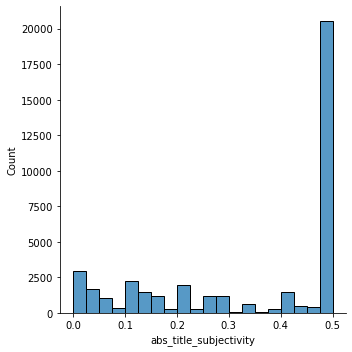

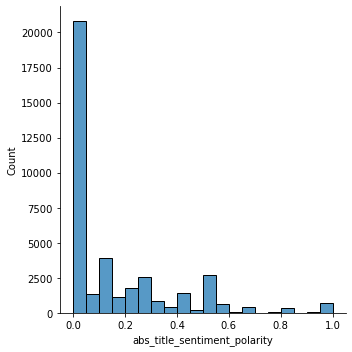

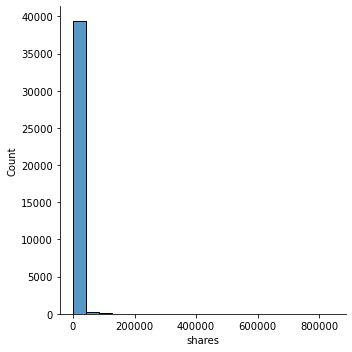

In [13]:
cols = list(data.columns)

for i in range(len(cols)):
    width = (data[cols[i]].max() - data[cols[i]].min()) / 20
    sns.displot(data, x=cols[i], binwidth=width)

In [14]:
print(data['shares'].quantile(0.95))
print(data['shares'].median())
print(data['shares'].mean())
print(data['shares'].max())

10800.0
1400.0
3395.618295574953
843300


### Check Correlation Between Features
The threshold I defined for the correlation is 0.7, columns will be dropped if correlation value higher than threshold.


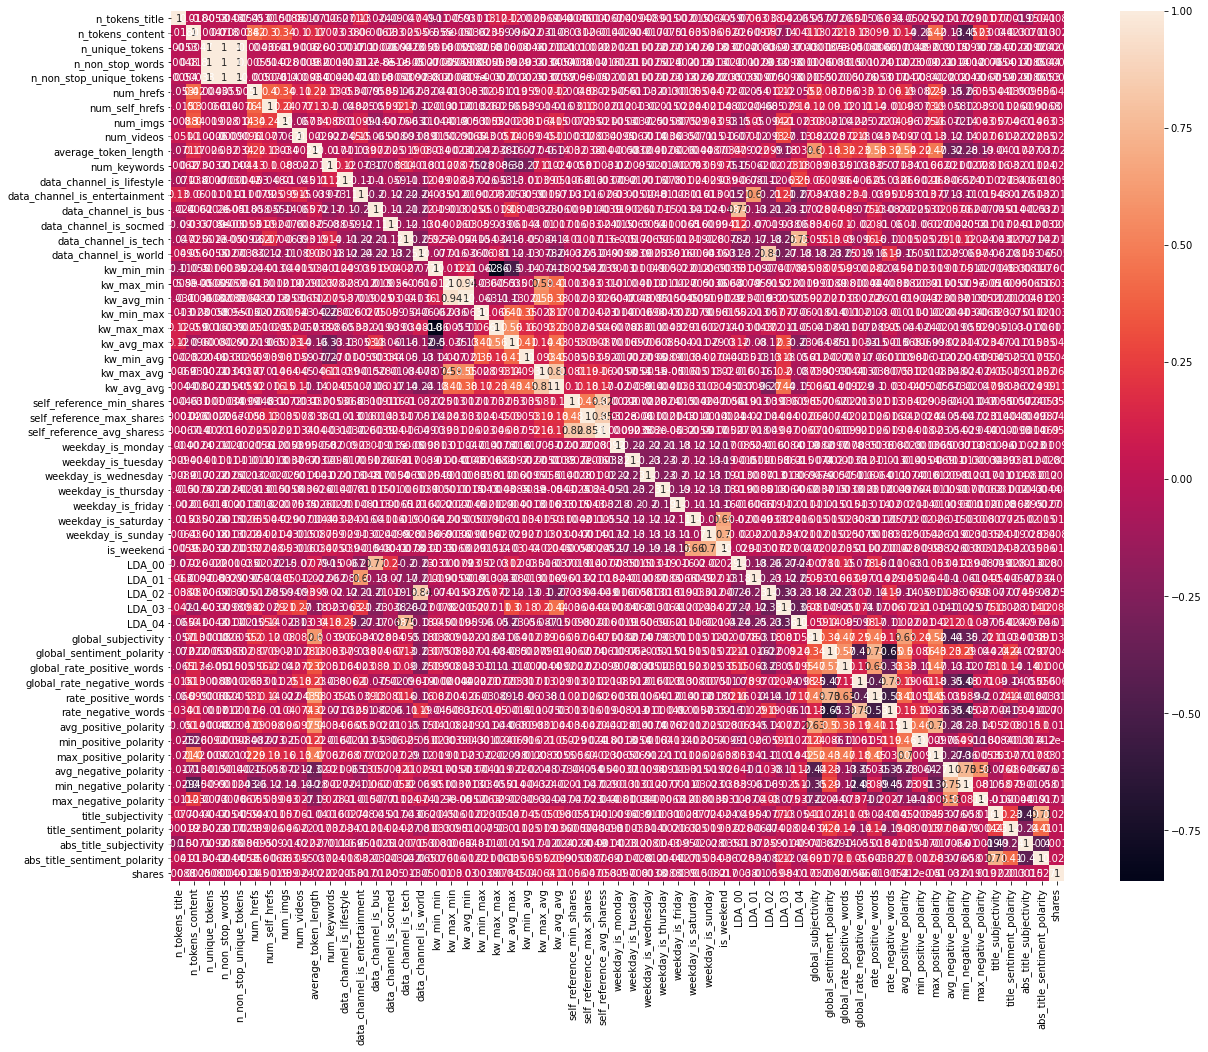

In [19]:
plt.subplots(figsize=(20, 16))
corr = data.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [25]:
corr_matrix = data.drop('shares', axis=1).corr().abs()

# Keep upper triangular matrix only
corr_result = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool_)
    )

corr_matrix

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
n_tokens_title,1.000000,0.018333,0.005329,0.004755,0.005429,0.053347,0.014735,0.008844,0.051477,0.071455,...,0.049544,0.025225,0.021492,0.017218,0.029322,0.011386,0.077309,0.000190,0.146889,0.040593
n_tokens_content,0.018333,1.000000,0.004732,0.017513,0.000378,0.423031,0.304619,0.342592,0.103708,0.167821,...,0.135099,0.261442,0.415670,0.130315,0.450580,0.225890,0.004419,0.023397,0.007107,0.013410
n_unique_tokens,0.005329,0.004732,1.000000,0.999572,0.999852,0.004348,0.006625,0.018804,0.000597,0.026405,...,0.000483,0.009191,0.009049,0.001450,0.009900,0.007315,0.004677,0.002335,0.009239,0.004216
n_non_stop_words,0.004755,0.017513,0.999572,1.000000,0.999532,0.005522,0.013599,0.028488,0.000899,0.031554,...,0.002285,0.000904,0.002062,0.001372,0.001214,0.000761,0.005390,0.001650,0.008512,0.004392
n_non_stop_unique_tokens,0.005429,0.000378,0.999852,0.999532,1.000000,0.004980,0.007590,0.014233,0.000962,0.034184,...,0.004675,0.008378,0.002240,0.001975,0.004316,0.006708,0.005858,0.002912,0.008570,0.005341
num_hrefs,0.053347,0.423031,0.004348,0.005522,0.004980,1.000000,0.396435,0.342654,0.114548,0.222624,...,0.188228,0.082063,0.286677,0.152008,0.263441,0.055003,0.043822,0.039019,0.009497,0.056462
num_self_hrefs,0.014735,0.304619,0.006625,0.013599,0.007590,0.396435,1.000000,0.238562,0.077462,0.126899,...,0.098081,0.072607,0.189887,0.058175,0.122056,0.039147,0.011361,0.026274,0.008979,0.006767
num_imgs,0.008844,0.342592,0.018804,0.028488,0.014233,0.342654,0.238562,1.000000,0.067332,0.033948,...,0.096436,0.024671,0.155171,0.072499,0.136533,0.042599,0.056765,0.046336,0.013767,0.063288
num_videos,0.051477,0.103708,0.000597,0.000899,0.000962,0.114548,0.077462,0.067332,1.000000,0.002944,...,0.097446,0.010113,0.125679,0.115992,0.138222,0.027260,0.061034,0.021969,0.021980,0.055221
average_token_length,0.071455,0.167821,0.026405,0.031554,0.034184,0.222624,0.126899,0.033948,0.002944,1.000000,...,0.540235,0.222210,0.471522,0.324560,0.278836,0.194652,0.040442,0.016744,0.026649,0.036972


In [27]:
# Find columns that correlation score > 0.7
drop_cols = [col for col in corr_result.columns 
                 if any(corr_result[col] > 0.7)
             ]

drop_result = corr_result[corr_result.index == -1].T
drop_result['DROP'] = drop_result.index.isin(drop_cols)
drop_result = drop_result.T
corr_result = corr_result.append(drop_result)

keep_cols = corr_result[~corr_result.index.isin(drop_cols)]
keep_cols = keep_cols.drop(drop_cols, axis=1)

In [28]:
data = data.drop(drop_cols, axis=1)

In [29]:
drop_cols

['n_non_stop_words',
 'n_non_stop_unique_tokens',
 'kw_avg_min',
 'kw_max_max',
 'kw_avg_avg',
 'self_reference_avg_sharess',
 'is_weekend',
 'LDA_00',
 'LDA_02',
 'LDA_04',
 'rate_positive_words',
 'rate_negative_words',
 'max_positive_polarity',
 'min_negative_polarity',
 'abs_title_sentiment_polarity']

### Detect and drop outliers

I regard shares over 99th quantile as outliers and drop them.

In [14]:
def df_drop_outlier(df, cols, quantile=0.995, preview=False):    
    loc_df = df.copy()
    
    for i in range(len(cols)):
        col = cols[i]
        threshold = loc_df[col].quantile(quantile)
        loc_df['DROP'] = np.where(loc_df[col]>threshold, 1, 0)
        
        if preview:
            chk = loc_df[loc_df['DROP']==1]
            if len(chk) > 0:
                print('df_drop_outlier -', col, len(chk) )
        else:
            loc_df = loc_df[loc_df['DROP']==0].drop('DROP', axis=1)
            
    if not preview:
        return loc_df

In [15]:
cols = list(data.columns)
df_drop_outlier(df=data, cols=cols, quantile=0.99, preview=True)
data = data.drop('abs_title_subjectivity', axis=1)

df_drop_outlier - n_tokens_title 380
df_drop_outlier - n_tokens_content 397
df_drop_outlier - n_unique_tokens 397
df_drop_outlier - num_hrefs 379
df_drop_outlier - num_self_hrefs 372
df_drop_outlier - num_imgs 384
df_drop_outlier - num_videos 373
df_drop_outlier - average_token_length 397
df_drop_outlier - kw_min_min 4
df_drop_outlier - kw_max_min 393
df_drop_outlier - kw_min_max 380
df_drop_outlier - kw_avg_max 395
df_drop_outlier - kw_min_avg 391
df_drop_outlier - kw_max_avg 396
df_drop_outlier - self_reference_min_shares 389
df_drop_outlier - self_reference_max_shares 396
df_drop_outlier - LDA_01 397
df_drop_outlier - LDA_03 397
df_drop_outlier - global_subjectivity 397
df_drop_outlier - global_sentiment_polarity 397
df_drop_outlier - global_rate_positive_words 397
df_drop_outlier - global_rate_negative_words 397
df_drop_outlier - avg_positive_polarity 393
df_drop_outlier - min_positive_polarity 325
df_drop_outlier - shares 397


In [16]:
cols = list(data.columns)
data = df_drop_outlier(df=data, cols=cols, quantile=0.99, preview=False)

### EDA Summary

15 columns are dropped because of correlation, and I set 99th percentile as the threshold of the outliers. Through the plot histogram, I find the distribution of shares is really skewed, and the range is huge. To make models preciting well, I will scale data with log transform in the next part.

## 4. Perform Analysis Using Supervised Machine Learning Models of your Choice, Present Discussion and Conclusions

### Scale Data With Log Transform

Because the target variable is skewed, so I decide to scale the data with log transform.

In [17]:
scaler = FunctionTransformer(np.log1p, inverse_func=np.expm1)
data_scaled = scaler.transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

In [18]:
# The data type of some columns are object, but it should be float.
cols = list(data_scaled.columns)
for col in cols:
    data_scaled[col] = data_scaled[col].astype('float')

In [19]:
# More than 30% rows in kw_min_min are -inf after scaling, so I drop this column
data_scaled = data_scaled.drop('kw_min_min', axis=1)

In [21]:
for c in data_scaled.columns:
    data_scaled = data_scaled[data_scaled[c].abs()<np.inf]

In [22]:
data_scaled = data_scaled.dropna(axis=0)

In [23]:
# Split train set and test set
X = data_scaled.drop('shares', axis=1)
y = data_scaled['shares']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_test_inverse = scaler.inverse_transform(y_test)

### Training Model

In this part, I will train three models, including linear regression, support vector machine, and XGBoost. I regard linear regression as a baseline model, and expect SVM and XGBoost can predict well than linear regression. Furthermore, I will use GridSearchCV to tune hyperparameters and execute cross validation.

**Linear Regression**

In [24]:
model = LinearRegression().fit(X_train, y_train)
model.score(X_train, y_train)

0.1144759183456161

In [25]:
# Predict
y_pred = model.predict(X_test)

# Inverse Transform
y_pred_inverse = scaler.inverse_transform(y_pred)

# Calculate MSE
mean_squared_error(y_test_inverse, y_pred_inverse)

13270989.10486348

In [26]:
mean_squared_error(y_test_inverse, y_pred_inverse)

13270989.10486348

**Support Vector Machine**

In [27]:
params = {'C': [1, 2],
          'degree': [3, 4],
          'epsilon':[0.1, 0.3]
         }

model = GridSearchCV(SVR(), params, cv=3)
model.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVR(),
             param_grid={'C': [1, 2], 'degree': [3, 4], 'epsilon': [0.1, 0.3]})

In [28]:
model.cv_results_

{'mean_fit_time': array([26.05067611, 19.14920211, 25.65355873, 19.04252632, 26.22066967,
        19.40740697, 26.14170043, 19.40881101]),
 'std_fit_time': array([0.18081576, 0.04883612, 0.13386039, 0.07242361, 0.47666549,
        0.113271  , 0.25677187, 0.07956844]),
 'mean_score_time': array([41.35968653, 30.11360637, 39.84700251, 29.66319633, 38.89445599,
        29.44244568, 40.29484542, 29.34079599]),
 'std_score_time': array([0.73948238, 0.111761  , 0.89347328, 0.75171205, 0.18948098,
        0.61091246, 1.08429352, 0.6671527 ]),
 'param_C': masked_array(data=[1, 1, 1, 1, 2, 2, 2, 2],
              mask=[False, False, False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_degree': masked_array(data=[3, 3, 4, 4, 3, 3, 4, 4],
              mask=[False, False, False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_epsilon': masked_array(data=[0.1, 0.3, 0.1, 0.3, 0.1, 0.3, 0.1, 0.3],
     

In [29]:
# Predict
y_pred = model.best_estimator_.predict(X_test)

# Inverse Transform
y_pred_inverse = scaler.inverse_transform(y_pred)

# Calculate MSE
mean_squared_error(y_test_inverse, y_pred_inverse)

13494088.712770458

In [30]:
mean_squared_error(y_test_inverse, y_pred_inverse)

13494088.712770458

**XGBoost**

In [31]:
params = {'eta': [0.05, 0.08],
          'min_child_weight': [1],
          'max_depth':[6, 8],
          'n_estimators':[100, 200],
         }

model = GridSearchCV(xgb.XGBRegressor(), params, cv=3)
model.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None,
                                    enable_categorical=False, gamma=None,
                                    gpu_id=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n_estimators=100, n_jobs=None,
                                    num_parallel_tree=None, predictor=None,
                                    random_state=None, reg_alpha=None,
                                    reg_lambda=None, scale_pos_weight=None,
       

In [32]:
model.best_score_

0.1623569232181119

In [33]:
model.cv_results_

{'mean_fit_time': array([3.19488533, 6.73804553, 4.60218898, 9.02372726, 3.18392269,
        6.05916397, 4.26389559, 8.38305704]),
 'std_fit_time': array([0.08435902, 0.0205315 , 0.06576951, 0.20839883, 0.07212403,
        0.22297398, 0.17949555, 0.21516289]),
 'mean_score_time': array([0.01416802, 0.01960365, 0.01605654, 0.02487008, 0.01659815,
        0.0202024 , 0.01860507, 0.02710422]),
 'std_score_time': array([0.00068591, 0.00324662, 0.00116818, 0.00435312, 0.00091189,
        0.00095705, 0.00174782, 0.00051514]),
 'param_eta': masked_array(data=[0.05, 0.05, 0.05, 0.05, 0.08, 0.08, 0.08, 0.08],
              mask=[False, False, False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_depth': masked_array(data=[6, 6, 8, 8, 6, 6, 8, 8],
              mask=[False, False, False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_min_child_weight': masked_array(data=[1, 1, 1, 1, 1, 1, 1, 1],

### Mean Square Error

In [34]:
# Predict
y_pred = model.best_estimator_.predict(X_test)

# Inverse Transform
y_pred_inverse = scaler.inverse_transform(y_pred)

# Calculate MSE
mean_squared_error(y_test_inverse, y_pred_inverse)

12962309.055601666

In [35]:
mean_squared_error(y_test_inverse, y_pred_inverse)

12962309.055601666

### Show Features

In [36]:
features = list(X_train.columns)

In [47]:
features_importance = model.best_estimator_.feature_importances_
features_importance = pd.DataFrame(features_importance, columns=['Importance'])
features_importance['Feature'] = features
features_importance = features_importance[['Feature', 'Importance']] \
                        .sort_values(by='Importance', ascending=False) \
                        .reset_index(drop=True)

In [48]:
features_importance

,Feature,Importance
0,data_channel_is_tech,0.084288
1,kw_max_avg,0.071519
2,data_channel_is_world,0.063253
3,self_reference_min_shares,0.057554
4,weekday_is_sunday,0.047609
5,weekday_is_saturday,0.044523
6,data_channel_is_socmed,0.044361
7,self_reference_max_shares,0.040629
8,data_channel_is_entertainment,0.039282
9,kw_min_avg,0.029500


### Training Summary

Though the performance of three models are bad, but XGBoost still outperform than others. So I think XGBoost is appropriate to be the first option when facing a new problem. For SVM, the r-squared is better than linear regression, but the MSE is worse. It's a good example that evaluating models with multiple metics is essential.

If we want to improve the performance with the same dataset, maybe we can try to build a more complicated model like neural network.



## Conclusion

Overall, the prediction result is bad, and I think there are two reasons. First, this dataset only contains information about the content, without any external data, like the data from Google Trends, so it is hard to predict precisely. Second, the instance of whole dataset is 39644, it is not enough to build a great model. Collecting more data is essential if we want to enhance the model.

Through this project, I learned that log transform is helpful in some case. Before I applied log transform, the r-squared of XGBoost was only 0.07, and it became 0.16 after scaling.

